# Estruturas de dados - Listas Ligadas
(Parte 2)

### Representando uma lista ligada

Vamos começar representando um nó em C, através de `structs`.

In [4]:
#include<stdio.h>

struct no {
    int info;         // informação do nó
    struct no * prox; // ponteiro para o próximo nó. É auto-referência!
};

Cada nó da lista tem:
- `info`: o valor armazenado
- `prox`: um ponteiro para o próximo nó da lista

Dessa maneira podemos começar a brincar com listas ligadas.

Como podemos criar uma lista que seja `1 -> 2 -> 3`, por exemplo?

Precisamos criar um ponteiro para ser o início da lista.

```c
struct no * lista;
```

### Revisão

Até agora vimos as seguintes funções de listas:
```c
    // Função que cria um novo nó
    struct no * novoNo(int info);

    // Função para inserir um nó no início da lista
    // retorna um ponteiro para o novo início (deve ser usado para atualizar o início)
    struct no * insert_first(struct no * lista, int info);

    // Função para inserir no final da lista
    // retorna void
    void insert_last(struct no * lista, int info);

    // Função para remover o primeiro elemento
    // retorna o novo inicio da lista (já que o antigo foi removido)
    struct no * remove_first(struct no * lista);
```

Ainda não fizemos uma função específica para percorrer e imprimir uma lista. 

Como podemos desenvolver esta função? 🤔

```c
    void printList(struct no * list) {








        

    }
```

#### Solução

In [9]:
#include<stdio.h>

// Estrutura que determina um nó da lista
struct no {
    int info;         
    struct no * prox;
};

// Função que cria um novo nó
struct no * novoNo(int info) {
    struct no * novo = malloc(sizeof(struct no));
    novo->info = info;
    return novo;
}

// Função para inserir um nó no início da lista
// retorna um ponteiro para o novo início (deve ser usado para atualizar o início)
struct no * insert_first(struct no * lista, int info) {
    struct no *novo = novoNo(info);
    if (!novo) return lista;   // se falhar, mantém a lista como estava
    novo->prox = lista;        // novo aponta para a antiga cabeça
    return novo;               // novo vira a cabeça
}

// Função para inserir no final da lista (que tenha sido inicializada)
// retorna void
void insert_last(struct no * lista, int info) {
    struct no *novo = novoNo(info);
    // Precisamos encontrar o último elemento da lista. Quando encontramos, adicionamos o novo!
    struct no *curr = lista;
    if (curr == NULL) {
        curr = novo;
        return;
    }
    while (curr->prox != NULL) {
        curr = curr->prox;
    }
    curr->prox = novo;
}

// Função para remover o primeiro elemento
// retorna o novo inicio da lista (já que o antigo foi removido)
struct no * remove_first(struct no * lista) {
    if (lista == NULL) return NULL; // lista vazia

    struct no *novo_inicio = lista->prox;
    return novo_inicio;
}

void printList(struct no * list) {
    struct no * curr = list;
    while (curr != NULL) {
        printf("%d", curr->info);
        if (curr->prox != NULL)
            printf(" -> ");
        curr = curr->prox;
    }
}

int main() {
    struct no * lista = novoNo(1);
    for (int i = 2; i <= 20; i++) {
        insert_last(lista, i);
    }

    printList(lista);
    
    printf("\n\n");
}

1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9 -> 10 -> 11 -> 12 -> 13 -> 14 -> 15 -> 16 -> 17 -> 18 -> 19 -> 20



Dessa maneira, temos a função assim:
```c
    void printList(struct no * list) {
        struct no * curr = list;
        while (curr != NULL) {
            printf("%d", curr->info);
            if (curr->prox != NULL)
                printf(" -> ");
            curr = curr->prox;
        }
    }
```

Será que podemos fazê-la diferente?

#### Solução

```c
    void printList(struct no * list) {
        for (struct no * curr = list; curr != NULL; curr = curr->prox) {
            printf("%d", curr->info);
            if (curr->prox != NULL)
                printf(" -> ");
        }
    }
```

In [12]:
#include<stdio.h>

// Estrutura que determina um nó da lista
struct no {
    int info;         
    struct no * prox;
};

// Função que cria um novo nó
struct no * novoNo(int info) {
    struct no * novo = malloc(sizeof(struct no));
    novo->info = info;
    return novo;
}

// Função para inserir um nó no início da lista
// retorna um ponteiro para o novo início (deve ser usado para atualizar o início)
struct no * insert_first(struct no * lista, int info) {
    struct no *novo = novoNo(info);
    if (!novo) return lista;   // se falhar, mantém a lista como estava
    novo->prox = lista;        // novo aponta para a antiga cabeça
    return novo;               // novo vira a cabeça
}

// Função para inserir no final da lista (que tenha sido inicializada)
// retorna void
void insert_last(struct no * lista, int info) {
    struct no *novo = novoNo(info);
    // Precisamos encontrar o último elemento da lista. Quando encontramos, adicionamos o novo!
    struct no *curr = lista;
    if (curr == NULL) {
        curr = novo;
        return;
    }
    while (curr->prox != NULL) {
        curr = curr->prox;
    }
    curr->prox = novo;
}

// Função para remover o primeiro elemento
// retorna o novo inicio da lista (já que o antigo foi removido)
struct no * remove_first(struct no * lista) {
    if (lista == NULL) return NULL; // lista vazia

    struct no *novo_inicio = lista->prox;
    return novo_inicio;
}

void printList(struct no * list) {
    for (struct no * curr = list; curr != NULL; curr = curr->prox) {
        printf("%d", curr->info);
        if (curr->prox != NULL)
            printf(" -> ");
    }
}

int main() {
    struct no * lista = novoNo(1);
    for (int i = 2; i <= 20; i++) {
        insert_last(lista, i);
    }

    printList(lista);
    
    printf("\n\n");
}

1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9 -> 10 -> 11 -> 12 -> 13 -> 14 -> 15 -> 16 -> 17 -> 18 -> 19 -> 20



## Novo conteúdo

### Liberando a memória

Uma coisa muito importante de lembrarmos é que a linguagem C nos permite ter controle total sobre a memória. Quando usamos `malloc`, estamos realizando uma alocação dinâmica de memória. Mas não podemos deixar a responsabilidade de lidar com essa memória de lado, se não fizermos uma liberação explícita dessa memória pedida, o programa pode acabar caindo no famoso problema de `memory leak`, o vazamento de memória.

#### Verificando o programa

Como verificar se nosso programa está com `memory leak`?

Existe um programa de instrumentação para C chamado `valgrind`, que faz o profiling da execução. Ao executar seu programa com o valgrind, você ganha uma análise do que está ocorrendo, inclusive se existe perda de memória durante sua execução. 

Podemos compilar o programa com o `gcc` e depois executar com o `valgrind`, por exemplo:

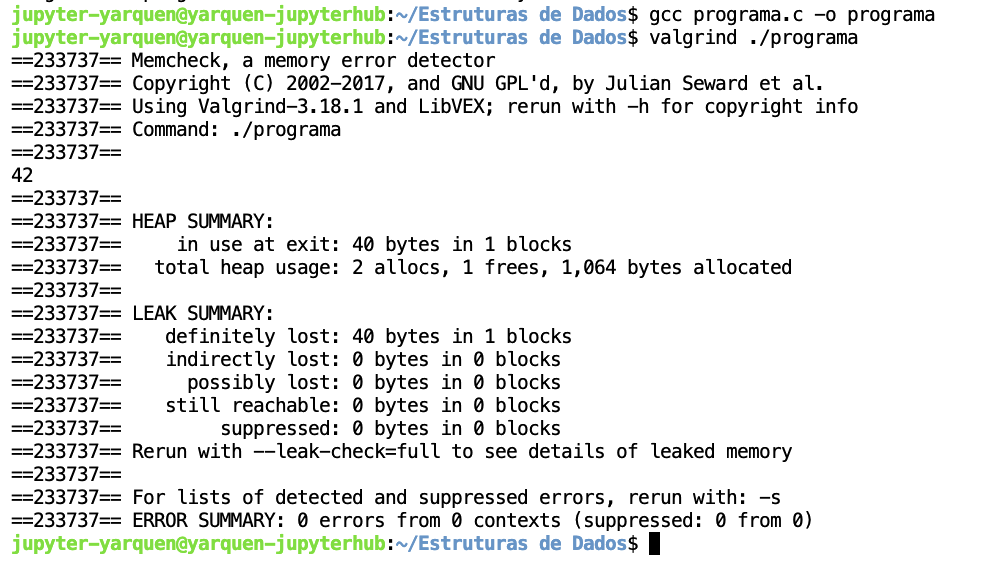

Neste exemplo, vemos que temos a mensagem `definitely lost` com uma quantidade de `40 bytes`.
Logo, o programa executado tem, de fato, `memory leak`. Mas como evitar o memory leak? Usando `free`!

Vamos verificar o programa executado:

```c
#include <stdio.h>
#include <stdlib.h>

int main() {
    int *v = malloc(10 * sizeof(int));
    v[0] = 42;
    printf("%d\n", v[0]);
    return 0;
}
```

Este programa aloca a memória, colocando no ponteiro `int * v`, mas nunca faz sua liberação. O que falta aqui? Usar o `free` para liberar o ponteiro:

```c
#include <stdio.h>
#include <stdlib.h>

int main() {
    int *v = malloc(10 * sizeof(int));
    v[0] = 42;
    printf("%d\n", v[0]);
    free(v);
    return 0;
}
```

Depois de compilar e executar com `valgrind`, temos o efeito do `free` aplicado, mostrando que não existem mais o problema de `memory leak`.

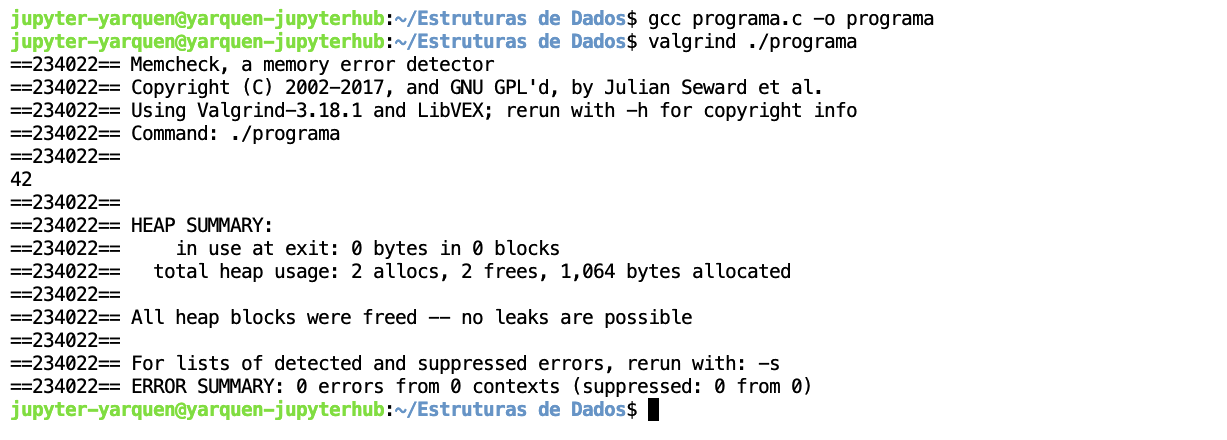



#### Liberando a lista ligada

Como podemos garantir que nosso programa que usa listas ligadas não tenha memory leak?

Usamos o `free` para todos os ponteiros que estejam na lista ligada. 

```c
void freeList(struct no * lista) {
    if (!lista) return;

    struct no *curr = lista;
    while (curr != NULL) {
        struct no * proximo = curr->prox;
        free(curr);
        curr = proximo;
    }
}
```


### Lista ligada com cabeça

Pode ser útil termos um “marcador de início” para nossa lista ligada. Desse jeito, a primeira célula da lista será, efetivamente, a que a cabeça aponta. 

Hoje temos um ponteiro `lista` que aponta para o primeiro nó efetivo da lista. Com a lista com cabeça, o ponteiro vai sempre apontar para a `cabeça` (ou `nó sentinela`).

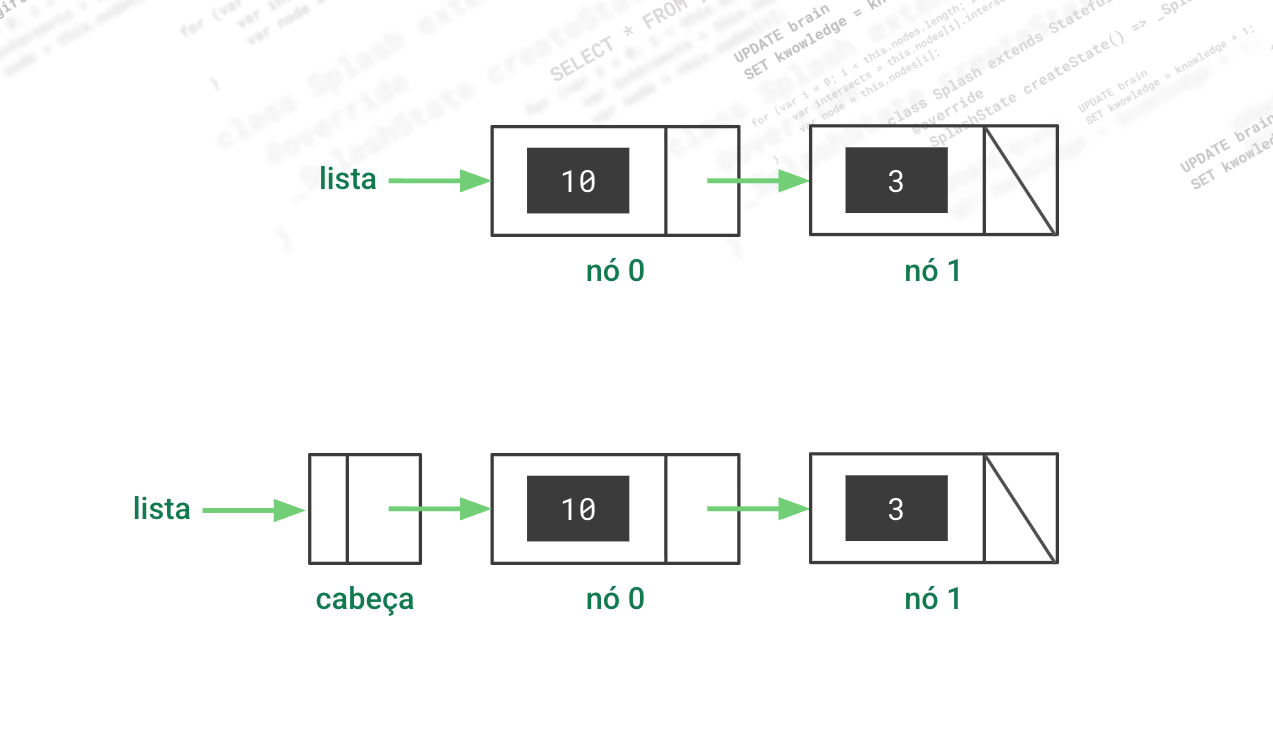

Na implementação atual, se removermos o primeiro item, o ponteiro muda. Se inserirmos no início, o ponteiro muda. É por isso que retornamos um `struct no *` nas funções que inserem e removem.

Com a ideia da lista ligada com cabeça, isso muda! É um nó que só existe para facilitar nossa estrutura de dados.
Agora `lista` não aponta mais para o primeiro dado efetivo, mas sim para o nó cabeça. Assim, o primeiro elemento está em `lista->prox`.

#### Conceitos fundamentais

**1. Lista nunca é NULL**

Em uma lista com cabeça, nossa `lista` nunca assume o valor de NULL. Dessa maneira, para verificar se a lista está vazia, fazemos:

```c
lista->prox == NULL
```

**2. A inserção no início não muda o ponteiro base**
Antes, fazíamos:

```c
novo->prox = lista;
return novo;
```

Agora, faremos:
```c
novo->prox = lista->prox;
lista->prox = novo;
```

Por isso, não precisamos mais retornar o novo nó inserido!

**3. Remover o primeiro também não troca a lista**
Antes, fazíamos:

```c
struct no * novo_inicio = lista->prox;
return novo_inicio;
```

Agora, faremos:
```c
struct no * removido = lista->prox;
lista->prox = removido->prox;
```

Removemos o elemento, mas a cabeça permanece.

In [13]:
#include <stdio.h>
#include <stdlib.h>

// Estrutura que determina um nó da lista
struct no {
    int info;
    struct no *prox;
};

// Função que cria um novo nó (nó "normal", com dado)
struct no *novoNo(int info) {
    struct no *novo = (struct no *)malloc(sizeof(struct no));
    if (!novo) return NULL;
    novo->info = info;
    novo->prox = NULL;
    return novo;
}

// Função que cria a cabeça (sentinela)
// A cabeça NÃO é um elemento "real" da lista; ela só aponta para o primeiro.
struct no *criaCabeca(void) {
    struct no *cabeca = (struct no *)malloc(sizeof(struct no));
    if (!cabeca) return NULL;
    cabeca->info = 0;     // valor irrelevante (sentinela)
    cabeca->prox = NULL;  // lista começa vazia
    return cabeca;
}

// Inserir no início (agora sempre depois da cabeça)
// Não precisa retornar o início, porque a cabeça nunca muda.
void insert_first(struct no *cabeca, int info) {
    if (!cabeca) return;

    struct no *novo = novoNo(info);
    if (!novo) return;

    novo->prox = cabeca->prox;
    cabeca->prox = novo;
}

// Inserir no final (percorrendo a partir da cabeça)
void insert_last(struct no *cabeca, int info) {
    if (!cabeca) return;

    struct no *novo = novoNo(info);
    if (!novo) return;

    struct no *curr = cabeca;
    while (curr->prox != NULL) {
        curr = curr->prox;
    }
    curr->prox = novo;
}

// Remover o primeiro elemento "real" (cabeca->prox)
void remove_first(struct no *cabeca) {
    if (!cabeca) return;           // sem cabeça
    if (cabeca->prox == NULL) return; // lista vazia

    struct no *removido = cabeca->prox;
    cabeca->prox = removido->prox;
    free(removido);
}

// Imprimir lista: começa do primeiro elemento real (cabeca->prox)
void printList(struct no *cabeca) {
    if (!cabeca) return;

    struct no *curr = cabeca->prox;
    while (curr != NULL) {
        printf("%d", curr->info);
        if (curr->prox != NULL)
            printf(" -> ");
        curr = curr->prox;
    }
}

void freeList(struct no *cabeca) {
    if (!cabeca) return;

    struct no *curr = cabeca->prox;
    while (curr != NULL) {
        struct no *next = curr->prox;
        free(curr);
        curr = next;
    }
    free(cabeca);
}

int main() {
    // Agora "lista" é a cabeça (sentinela)
    struct no *lista = criaCabeca();

    // Insere 1..20 como elementos reais
    for (int i = 1; i <= 20; i++) {
        insert_last(lista, i);
    }

    printList(lista);
    printf("\n\n");

    // exemplo: remover o primeiro
    remove_first(lista);
    printList(lista);
    printf("\n\n");

    freeList(lista);
    return 0;
}

1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9 -> 10 -> 11 -> 12 -> 13 -> 14 -> 15 -> 16 -> 17 -> 18 -> 19 -> 20

2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9 -> 10 -> 11 -> 12 -> 13 -> 14 -> 15 -> 16 -> 17 -> 18 -> 19 -> 20



#### Vamos analisar a inserção no fim

O algoritmo de inserção no fim está assim:

```c
// Inserir no final (percorrendo a partir da cabeça)
void insert_last(struct no *cabeca, int info) {
    if (!cabeca) return;

    struct no *novo = novoNo(info);
    if (!novo) return;

    struct no *curr = cabeca;
    while (curr->prox != NULL) {
        curr = curr->prox;
    }
    curr->prox = novo;
}
```

Sua complexidade de execução é de `O(n)`. Isso porque precisamos percorrer a lista inteira, a partir da cabeça, até encontrar o penúltimo nó e então inserir o novo nó.

Será que conseguimos melhorar esse caso?

### Uma nova representação para lista

Uma maneira de melhorarmos nossa lista é mudando sua representação. 

Que tal criarmos uma estrutura que nos auxilie a manter o rastreamento do início e do fim da lista? E mais legal ainda, que tal chamarmos essa estrutura de `Lista`?

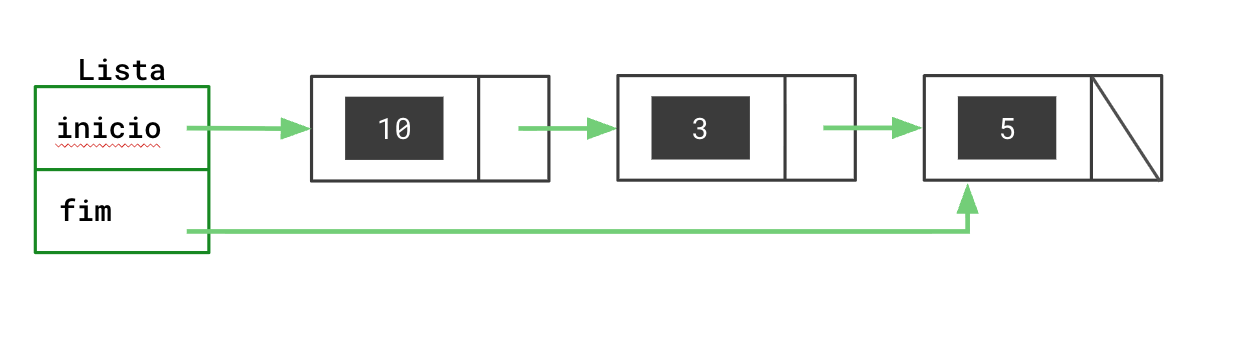

#### Uma nova maneira de escrever os tipos de lista

Segundo o verbete da Wikipedia, `typedef` é:

*"typedef is a reserved keyword in the programming languages C, C++, and Objective-C. It is used to create an additional name (alias) for another data type, but does not create a new type, except in the obscure case of a qualified typedef of an array type where the typedef qualifiers are transferred to the array element type. As such, it is often used to simplify the syntax of declaring complex data structures consisting of struct and union types, although it is also commonly used to provide specific descriptive type names for integer data types of varying sizes."*

Ou seja, podemos usar essa palavra reservada para criar um nome que representa um outro tipo de dado. Isso é bem útil para o nosso caso!

Podemos criar uma `struct` chamada no. Essa `struct no` terá um `typedef` chamado No. Dessa maneira, podemos dizer que uma `Celula` é um ponteiro de `No`. Assim, fica fácil de criarmos uma estrutura lista com o nome `Lista`, que tem duas propriedades do tipo `Celula`: `inicio` e `fim`.

```c
typedef struct no {
    int info;
    struct no * prox;
} No;

typedef No * Celula;

typedef struct lista {
    Celula inicio;
    Celula fim;
} Lista;
```

Isso facilita um pouco para não nos perdermos nos `*` de ponteiros o tempo todo 😉. Assim, podemos fazer algo simples, como:

##### Code

In [35]:
#include<stdio.h>
#include <stdlib.h>

/**
 Vamos usar o prefixo ll para todas as funções que são de Lista Ligada (dois l's)
*/

typedef struct no {
    int info;
    struct no * prox;
} No;

typedef No * Celula;

typedef struct lista {
    Celula inicio;
    Celula fim;
} Lista;

typedef Lista * ListaLigada;

ListaLigada novaLista() {
    ListaLigada l = malloc(sizeof(Lista));
    if (!l) return NULL;
    l->inicio = NULL;
    l->fim = NULL;
    return l;
}

Celula novaCelula(int info) {
    Celula celula = (Celula) malloc(sizeof(No));
    celula->info = info;
    celula->prox = NULL;

    return celula;
}

void llPrint(ListaLigada lista) {
    for (Celula aux = lista->inicio; aux != NULL; aux = aux->prox) {
        printf("%d", aux->info);
        if (aux->prox != NULL)
            printf(" -> ");
    }
    printf("\n");
}

void llInsereNoInicio(ListaLigada lista, int info) {
    Celula celula = novaCelula(info);
    if (lista->inicio == NULL) { // lista é vazia
        lista->inicio = celula;
        lista->fim = celula;
    }
    else {
        celula->prox = lista->inicio;
        lista->inicio = celula;
    }
}

int main() {
    ListaLigada lista = novaLista();

    for (int i = 1; i <= 20; i++) {
        llInsereNoInicio(lista, i);
    }

    llPrint(lista);

    return 0;
}

20 -> 19 -> 18 -> 17 -> 16 -> 15 -> 14 -> 13 -> 12 -> 11 -> 10 -> 9 -> 8 -> 7 -> 6 -> 5 -> 4 -> 3 -> 2 -> 1


#### Como fica a inserção no fim?

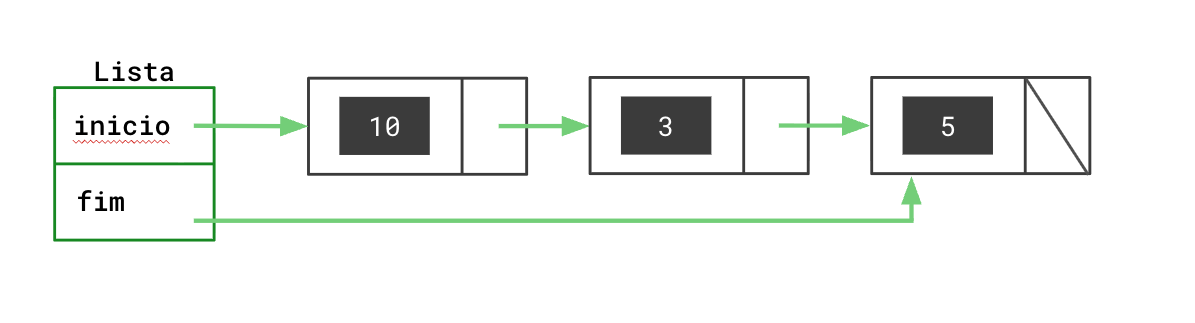

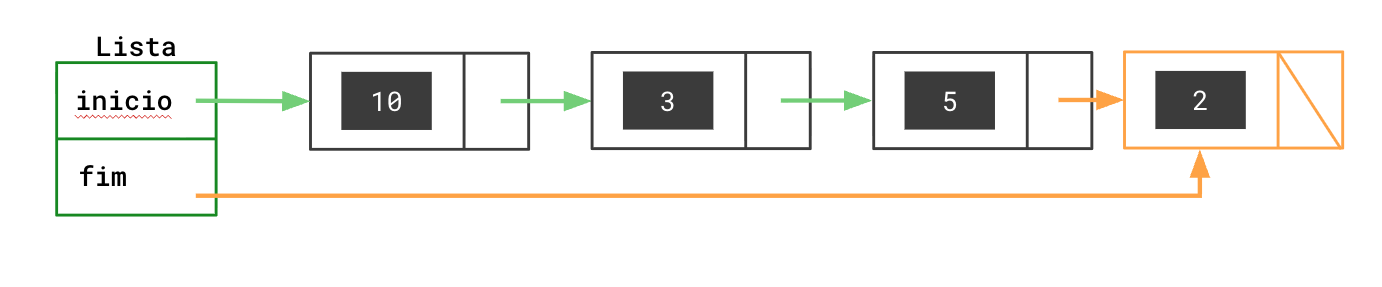

Com a nova estrutura, a complexidade de inserção no fim diminui para `O(1)`, porque temos o ponteiro de fim disponível!

```c
void llInsereNoFim(ListaLigada lista, int info) {
    Celula nova = novaCelula(info);
    
    lista->fim->prox = nova;
    lista->fim = nova;
}
```

Mas será que não existe problema aqui? 🤔

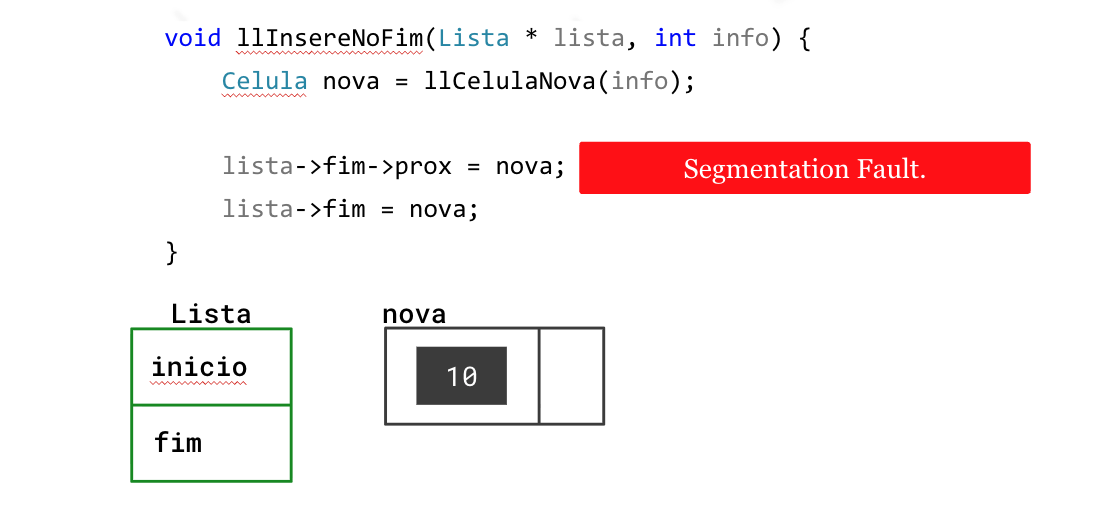

Ao tentar colocar o `prox` do fim para a nova `Celula`, o programa cai em um problema: não existe fim ainda, em uma lista vazia o `fim` e `inicio` apontam para `NULL`. Precisamos verificar se a lista está vazia antes de inserir no fim!

```c
void llInsereNoFim(ListaLigada lista, int info) {
    Celula nova = novaCelula(info);
    
    if (lista->inicio == NULL) { // ou seja, a lista está vazia
        lista->inicio = nova;
        lista->fim = nova;
        return;
    }
    lista->fim->prox = nova;
    lista->fim = nova;
}
```

##### Code

In [39]:
#include<stdio.h>
#include <stdlib.h>

/**
 Vamos usar o prefixo ll para todas as funções que são de Lista Ligada (dois l's)
*/

typedef struct no {
    int info;
    struct no * prox;
} No;

typedef No * Celula;

typedef struct lista {
    Celula inicio;
    Celula fim;
} Lista;

typedef Lista * ListaLigada;

ListaLigada novaLista() {
    ListaLigada l = malloc(sizeof(Lista));
    if (!l) return NULL;
    l->inicio = NULL;
    l->fim = NULL;
    return l;
}

Celula novaCelula(int info) {
    Celula celula = (Celula) malloc(sizeof(No));
    celula->info = info;
    celula->prox = NULL;

    return celula;
}

void llPrint(ListaLigada lista) {
    for (Celula aux = lista->inicio; aux != NULL; aux = aux->prox) {
        printf("%d", aux->info);
        if (aux->prox != NULL)
            printf(" -> ");
    }
    printf("\n");
}

void llInsereNoInicio(ListaLigada lista, int info) {
    Celula celula = novaCelula(info);
    if (lista->inicio == NULL) { // lista é vazia
        lista->inicio = celula;
        lista->fim = celula;
    }
    else {
        celula->prox = lista->inicio;
        lista->inicio = celula;
    }
}

void llInsereNoFim(ListaLigada lista, int info) {
    Celula nova = novaCelula(info);
    
    if (lista->inicio == NULL) { // ou seja, a lista está vazia
        lista->inicio = nova;
        lista->fim = nova;
        return;
    }
    lista->fim->prox = nova;
    lista->fim = nova;
}

int main() {
    ListaLigada lista = novaLista();

    for (int i = 1; i <= 20; i++) {
        llInsereNoFim(lista, i);
    }

    llPrint(lista);

    return 0;
}

1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9 -> 10 -> 11 -> 12 -> 13 -> 14 -> 15 -> 16 -> 17 -> 18 -> 19 -> 20


#### Como fica a remoção no início?

Para remover no início, só precisamos retirar o ponteiro de `inicio` e apontar para o `prox` de onde `inicio` apontava.
Só precisamos tomar cuidado com o caso da lista vazia:

```c
void llRemoveInicio(ListaLigada lista) {
    if (lista->inicio == NULL) {
        return;
    }

    Celula removido = lista->inicio;
    lista->inicio = removido->prox;
    free(removido); // liberando o ponteiro da Celula removida
}
```

##### Code

In [41]:
#include<stdio.h>
#include <stdlib.h>

/**
 Vamos usar o prefixo ll para todas as funções que são de Lista Ligada (dois l's)
*/

typedef struct no {
    int info;
    struct no * prox;
} No;

typedef No * Celula;

typedef struct lista {
    Celula inicio;
    Celula fim;
} Lista;

typedef Lista * ListaLigada;

ListaLigada novaLista() {
    ListaLigada l = malloc(sizeof(Lista));
    if (!l) return NULL;
    l->inicio = NULL;
    l->fim = NULL;
    return l;
}

Celula novaCelula(int info) {
    Celula celula = (Celula) malloc(sizeof(No));
    celula->info = info;
    celula->prox = NULL;

    return celula;
}

void llPrint(ListaLigada lista) {
    for (Celula aux = lista->inicio; aux != NULL; aux = aux->prox) {
        printf("%d", aux->info);
        if (aux->prox != NULL)
            printf(" -> ");
    }
    printf("\n");
}

void llInsereNoInicio(ListaLigada lista, int info) {
    Celula celula = novaCelula(info);
    if (lista->inicio == NULL) { // lista é vazia
        lista->inicio = celula;
        lista->fim = celula;
    }
    else {
        celula->prox = lista->inicio;
        lista->inicio = celula;
    }
}

void llInsereNoFim(ListaLigada lista, int info) {
    Celula nova = novaCelula(info);
    
    if (lista->inicio == NULL) { // ou seja, a lista está vazia
        lista->inicio = nova;
        lista->fim = nova;
        return;
    }
    lista->fim->prox = nova;
    lista->fim = nova;
}

void llRemoveInicio(ListaLigada lista) {
    if (lista->inicio == NULL) {
        return;
    }

    Celula removido = lista->inicio;
    lista->inicio = removido->prox;
    free(removido); // liberando o ponteiro da Celula removida
}

int main() {
    ListaLigada lista = novaLista();

    for (int i = 1; i <= 20; i++) {
        llInsereNoFim(lista, i);
    }

    llPrint(lista);

    llRemoveInicio(lista);
    llRemoveInicio(lista);
    llRemoveInicio(lista);

    llPrint(lista);

    return 0;
}

1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9 -> 10 -> 11 -> 12 -> 13 -> 14 -> 15 -> 16 -> 17 -> 18 -> 19 -> 20
4 -> 5 -> 6 -> 7 -> 8 -> 9 -> 10 -> 11 -> 12 -> 13 -> 14 -> 15 -> 16 -> 17 -> 18 -> 19 -> 20


#### Criando todas as funções da nossa Lista Ligada

Nós já implementamos algumas funções de listas ligadas, mas temos mais algumas para garantir nossa API de Lista Ligada completa, com inserções, remoções, busca e etc.
A lista de funções que faltam está abaixo:

```c
/*
    Insere um valor INFO depois de um ALVO determinado
*/
void llInsereDepoisDe(ListaLigada lista, int alvo, int info);

/*
    Insere um valor INFO antes de um ALVO determinado
*/
void llInsereAntesDe(ListaLigada lista, int alvo, int info);

/*
    Busca uma Celula a partir de info, retornando seu ponteiro
*/
Celula llBusca(ListaLigada lista, int info) {
    for (Celula aux = lista->inicio; aux != NULL; aux = aux->prox) {
        if (aux->info == info) {
            return aux;
        }
    }
    return NULL;
}

/*
    Remove uma Celula específica da Lista, baseado em seu valor info
*/
Celula llRemove(ListaLigada lista, int info);
```

##### Solução

```c
void llInsereDepoisDe(ListaLigada lista, int alvo, int info) {
    Celula nova = novaCelula(info);
    Celula buscada = llBusca(lista, alvo);
    if (buscada != NULL) { // encontrou!
        nova->prox = buscada->prox;
        buscada->prox = nova;
    }
    else {
        llInsereNoFim(lista, info);
        free(nova);
    }
}

void llInsereAntesDe(ListaLigada lista, int alvo, int info) {
    Celula nova = novaCelula(info);
    Celula aux = NULL;
    for (aux = lista->inicio; aux->prox != NULL && aux->prox->info != alvo; aux = aux->prox);
    if (aux->prox != NULL) { // encontrou!
        nova->prox = aux->prox;
        aux->prox = nova;
    }
    else {
        llInsereNoInicio(lista, info);
        free(nova);
    }
}

/*
    Busca uma Celula a partir de info, retornando seu ponteiro
*/
Celula llBusca(ListaLigada lista, int info) {
    for (Celula aux = lista->inicio; aux != NULL; aux = aux->prox) {
        if (aux->info == info) {
            return aux;
        }
    }
    return NULL;
}

/*
    Remove uma Celula específica da Lista, baseado em seu valor info
*/
Celula llRemove(ListaLigada lista, int alvo) {
    Celula aux = NULL;
    for (aux = lista->inicio; aux->prox != NULL && aux->prox->info != alvo; aux = aux->prox);
    if (aux != NULL) { // aux é a celula anterior ao no que quero remover
        Celula removido = aux->prox;
        aux->prox = aux->prox->prox;
        free(removido);
    }
    
    return NULL; // Não consegui fazer nada, retorna nulo...
}
```

###### Code

In [47]:
#include<stdio.h>
#include <stdlib.h>

/**
 Vamos usar o prefixo ll para todas as funções que são de Lista Ligada (dois l's)
*/

typedef struct no {
    int info;
    struct no * prox;
} No;

typedef No * Celula;

typedef struct lista {
    Celula inicio;
    Celula fim;
} Lista;

typedef Lista * ListaLigada;

ListaLigada novaLista() {
    ListaLigada l = malloc(sizeof(Lista));
    if (!l) return NULL;
    l->inicio = NULL;
    l->fim = NULL;
    return l;
}

Celula novaCelula(int info) {
    Celula celula = (Celula) malloc(sizeof(No));
    celula->info = info;
    celula->prox = NULL;

    return celula;
}

void llPrint(ListaLigada lista) {
    for (Celula aux = lista->inicio; aux != NULL; aux = aux->prox) {
        printf("%d", aux->info);
        if (aux->prox != NULL)
            printf(" -> ");
    }
    printf("\n");
}

void llInsereNoInicio(ListaLigada lista, int info) {
    Celula celula = novaCelula(info);
    if (lista->inicio == NULL) { // lista é vazia
        lista->inicio = celula;
        lista->fim = celula;
    }
    else {
        celula->prox = lista->inicio;
        lista->inicio = celula;
    }
}

void llInsereNoFim(ListaLigada lista, int info) {
    Celula nova = novaCelula(info);
    
    if (lista->inicio == NULL) { // ou seja, a lista está vazia
        lista->inicio = nova;
        lista->fim = nova;
        return;
    }
    lista->fim->prox = nova;
    lista->fim = nova;
}

void llRemoveInicio(ListaLigada lista) {
    if (lista->inicio == NULL) {
        return;
    }

    Celula removido = lista->inicio;
    lista->inicio = removido->prox;
    free(removido); // liberando o ponteiro da Celula removida
}

/*
    Busca uma Celula a partir de info, retornando seu ponteiro
*/
Celula llBusca(ListaLigada lista, int info) {
    for (Celula aux = lista->inicio; aux != NULL; aux = aux->prox) {
        if (aux->info == info) {
            return aux;
        }
    }
    return NULL;
}

void llInsereDepoisDe(ListaLigada lista, int alvo, int info) {
    Celula nova = novaCelula(info);
    Celula buscada = llBusca(lista, alvo);
    if (buscada != NULL) { // encontrou!
        nova->prox = buscada->prox;
        buscada->prox = nova;
    }
    else {
        llInsereNoFim(lista, info);
        free(nova);
    }
}

void llInsereAntesDe(ListaLigada lista, int alvo, int info) {
    Celula nova = novaCelula(info);
    Celula aux = NULL;
    for (aux = lista->inicio; aux->prox != NULL && aux->prox->info != alvo; aux = aux->prox);
    if (aux->prox != NULL) { // encontrou!
        nova->prox = aux->prox;
        aux->prox = nova;
    }
    else {
        llInsereNoInicio(lista, info);
        free(nova);
    }
}

/*
    Remove uma Celula específica da Lista, baseado em seu valor info
*/
Celula llRemove(ListaLigada lista, int alvo) {
    Celula aux = NULL;
    for (aux = lista->inicio; aux->prox != NULL && aux->prox->info != alvo; aux = aux->prox);
    if (aux != NULL) { // aux é a celula anterior ao no que quero remover
        Celula removido = aux->prox;
        aux->prox = aux->prox->prox;
        free(removido);
    }
    
    return NULL; // Não consegui fazer nada, retorna nulo...
}

int main() {
    ListaLigada lista = novaLista();

    for (int i = 1; i <= 10; i++) {
        llInsereNoFim(lista, i);
    }

    llPrint(lista);

    llRemove(lista, 5);
    llInsereDepoisDe(lista, 4, 15);
    
    llPrint(lista);

    return 0;
}

1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9 -> 10
1 -> 2 -> 3 -> 4 -> 15 -> 6 -> 7 -> 8 -> 9 -> 10


#### Como fica a remoção no fim?

A remoção no final é um pouco diferente. Quando retiramos a última célula, precisamos garantir que a penúltima célula continue apontando para a última, não basta apenas trocar o ponteiro do final.

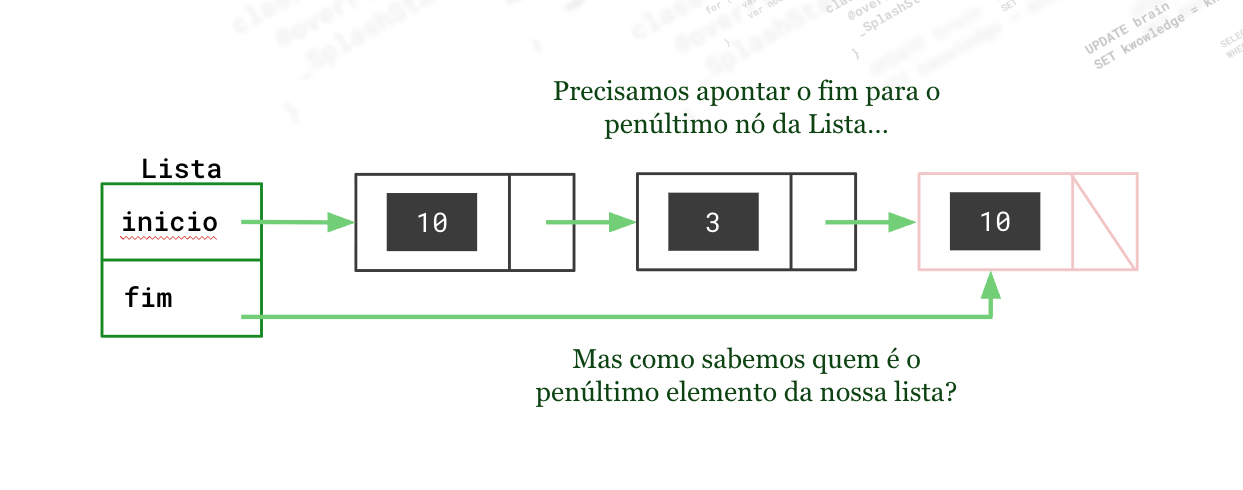

Para descobrir o penúltimo item, precisamos percorrer toda a lista...

```c
Celula aux = lista->inicio;
for(;aux->prox != NULL; aux = aux->prox){}
Celula penultima = aux;
```

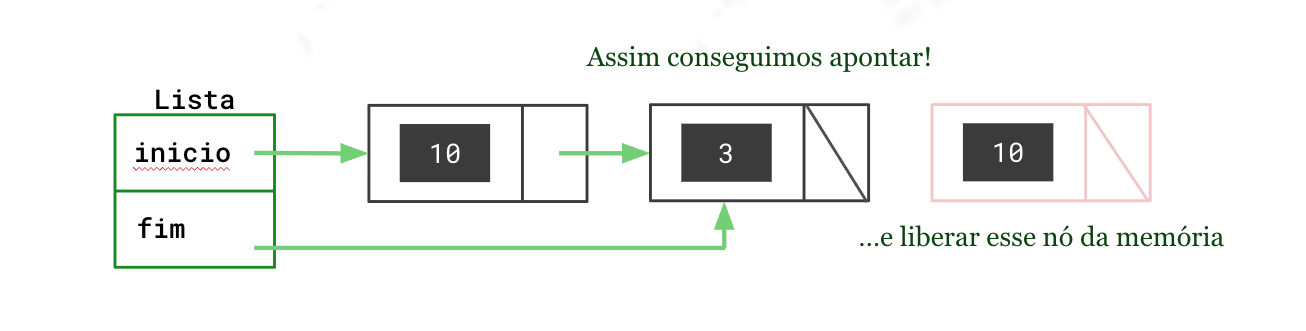

Podemos buscar a penultima Celula e então usá-la para remover o último item da lista.

```c
Celula llGetPenultimo(ListaLigada lista) {
    if (lista->inicio == NULL) {
        return NULL;
    }

    Celula penultimo = NULL;
    for(Celula aux = lista->inicio; aux->prox != NULL; aux = aux->prox) {
        penultimo = aux;
    }
    return penultimo;
}

void llRemoveFim(ListaLigada lista) {
    Celula penultimo = llGetPenultimo(lista);
    Celula removido = lista->fim;
    lista->fim = penultimo;
    penultimo->prox = NULL;
    free(removido);
}
```

Uma maneira de resolver esse problema é usando listas duplamente ligadas!